# Bayesian Hierarchical Time-Varying Analysis of Apartment Prices in Poland

## Reproducible Research Class &mdash; Team Project

* **Authors**: Levente Laszlo Szabo (*488761*), Xiao Li (*473533*), Szymon Grabowski (*473037*)
* **Affiliation**: [University of Warsaw](en.uw.edu.pl)
* **Published**: June 3, 2026

### Abstract
> This project aims to identify the key determinants of real estate prices across the 15 largest Polish cities (Warsaw, Krakow, Wroclaw, etc.) and to track how these determinants evolve over time. Because real estate data naturally possesses a nested structure (apartments are grouped within cities) and a temporal dimension (monthly snapshots from August 2023 to June 2024), applying traditional linear regression may lead to either underfitting (complete pooling) or overfitting (no pooling), while also failing to capture the dynamics of a changing housing market. \
To address this, we implement a **Bayesian Hierarchical Time-Varying Parameters (TVP) Model** using partial pooling and state-space formulations. This approach allows each city to have its own baseline price and price-sensitivity coefficients that evolve over time as random walks, while still sharing statistical strength across the entire national dataset.

### Setting up `Python`

In [1]:
import os
#os.chdir("")
os.getcwd()

import warnings
warnings.filterwarnings("ignore")

### Importing the packages

In [2]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")

import numpy as np

import pandas as pd
pd.options.display.max_colwidth = None
pd.options.display.max_seq_items = None
pd.set_option("display.precision", 4)

### Reading the dataset

In [3]:
df = pd.read_csv(
    "data\processed\master_sales_dataset.csv",
    sep = ",",
    decimal = ".",
    header = 0,
    index_col = "id",
    encoding = "utf-8"
)

### Getting the descriptive analysis

Attributes

In [4]:
print(
    "The dataset has", df.shape[0], "samples and", df.shape[1], "attributes.\n\n"
    "The name of the columns are:", list(df.columns), "\n\n"
    "The types of the attributes:\n", df.dtypes, "\n\n", df.dtypes.value_counts(), "\n\n"
    "The target variable is: 'price'"
)

The dataset has 195568 samples and 28 attributes.

The name of the columns are: ['city', 'type', 'squareMeters', 'rooms', 'floor', 'floorCount', 'buildYear', 'latitude', 'longitude', 'centreDistance', 'poiCount', 'schoolDistance', 'clinicDistance', 'postOfficeDistance', 'kindergartenDistance', 'restaurantDistance', 'collegeDistance', 'pharmacyDistance', 'ownership', 'buildingMaterial', 'condition', 'hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity', 'hasStorageRoom', 'price', 'snapshot_month'] 

The types of the attributes:
 city                        str
type                        str
squareMeters            float64
rooms                   float64
floor                   float64
floorCount              float64
buildYear               float64
latitude                float64
longitude               float64
centreDistance          float64
poiCount                float64
schoolDistance          float64
clinicDistance          float64
postOfficeDistance      float64
kindergart

Sample from dataset

In [5]:
df.sample(
    n = 3,
    random_state = 0
)

,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,...,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,snapshot_month
id,,,,,,,,,,,,,,,,,,,,,
bf66dc7e19fd542cb37737bffa62571a,gdansk,NaN,43.0,2.0,3.0,3.0,NaN,54.3471,18.6171,2.43,...,condominium,NaN,NaN,no,no,no,no,no,439000,2024-05
b079f12bf9225db964c939f4cd1ce7b2,bialystok,blockOfFlats,64.7,3.0,2.0,4.0,1990.0,53.1136,23.1464,2.20,...,condominium,NaN,NaN,no,yes,no,no,yes,499000,2023-12
09c87f786c95faf483fa9ecf8300b50b,radom,blockOfFlats,47.0,2.0,NaN,4.0,1969.0,51.4098,21.1617,1.54,...,condominium,concreteSlab,premium,no,no,NaN,no,no,360000,2023-10


Basic statistical indicators

In [6]:
df.describe(include = "all")

,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,...,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,snapshot_month
count,195568,153307,195568.0000,195568.0000,160974.0000,193185.0000,163352.0000,195568.0000,195568.0000,195568.0000,...,195568,118186,49261,195568,195568,185866,195568,195568,1.9557e+05,195568
unique,15,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,2,2,2,2,2,2,2,NaN,11
top,warszawa,blockOfFlats,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,condominium,brick,premium,no,yes,no,no,no,NaN,2024-06
freq,59246,91368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,176123,91899,27869,142410,112049,93662,173630,110583,NaN,21501
mean,NaN,NaN,58.6977,2.6792,3.3324,5.3091,1985.9763,52.0263,19.4660,4.3511,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.8418e+05,NaN
std,NaN,NaN,21.4072,0.9150,2.5317,3.3122,33.8128,1.3353,1.7833,2.8358,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0971e+05,NaN
min,NaN,NaN,25.0000,1.0000,1.0000,1.0000,1850.0000,49.9790,14.4471,0.0100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.5000e+05,NaN
25%,NaN,NaN,44.0000,2.0000,2.0000,3.0000,1967.0000,51.1088,18.5233,2.0100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.2000e+05,NaN
50%,NaN,NaN,54.6000,3.0000,3.0000,4.0000,1994.0000,52.1946,19.8994,3.9800,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.9900e+05,NaN
75%,NaN,NaN,68.5500,3.0000,4.0000,6.0000,2016.0000,52.4090,20.9899,6.1500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.3000e+05,NaN


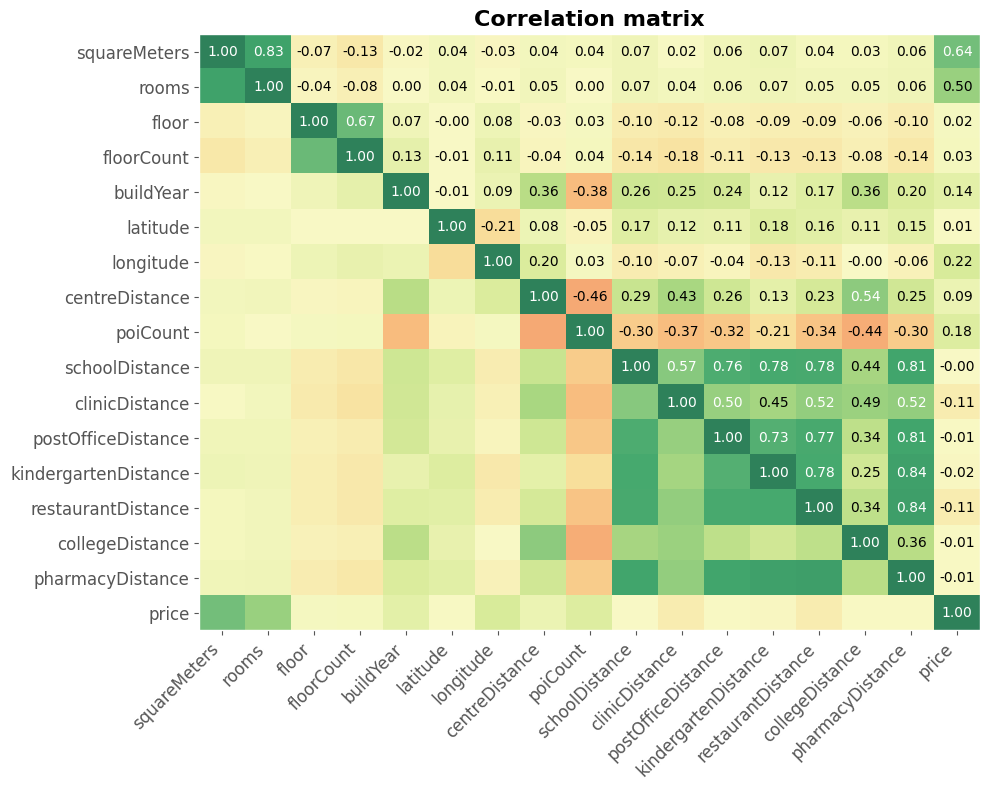

In [7]:
fig, ax = plt.subplots(
    figsize = (10, 8)
)

im = ax.imshow(
    df.select_dtypes(exclude=["object"]).corr(),
    cmap = "RdYlGn",
    aspect = "auto",
    vmin = -1,
    vmax = 1,
    alpha = 0.8
)
ax.set_title(
    label = "Correlation matrix",
    fontsize = 16,
    fontweight = "bold"
)
ax.set_xticks(
    np.arange(
        len(
            df.select_dtypes(exclude=["object"]).corr().columns
        )
    )
)
ax.set_yticks(
    np.arange(
        len(
            df.select_dtypes(exclude=["object"]).corr().columns
        )
    )
)
ax.set_xticklabels(
    df.select_dtypes(exclude=["object"]).corr().columns,
    rotation = 45,
    ha = "right",
    fontsize = 12
)
ax.set_yticklabels(
    df.select_dtypes(exclude=["object"]).corr().columns,
    fontsize = 12
)

for i in range(len(df.select_dtypes(exclude=["object"]).corr().columns)):
    for j in range(i, len(df.select_dtypes(exclude=["object"]).corr().columns)):
        text = ax.text(
            x = j,
            y = i,
            s = f'{df.select_dtypes(exclude=["object"]).corr().iloc[i, j]:.2f}',
            ha = "center",
            va = "center",
            color = "white" if abs(df.select_dtypes(exclude=["object"]).corr().iloc[i, j]) > 0.5 else "black",
            fontweight = "normal",
            fontsize = 10
        )

plt.grid(False)
plt.tight_layout()
plt.show()
plt.close()

Target variable

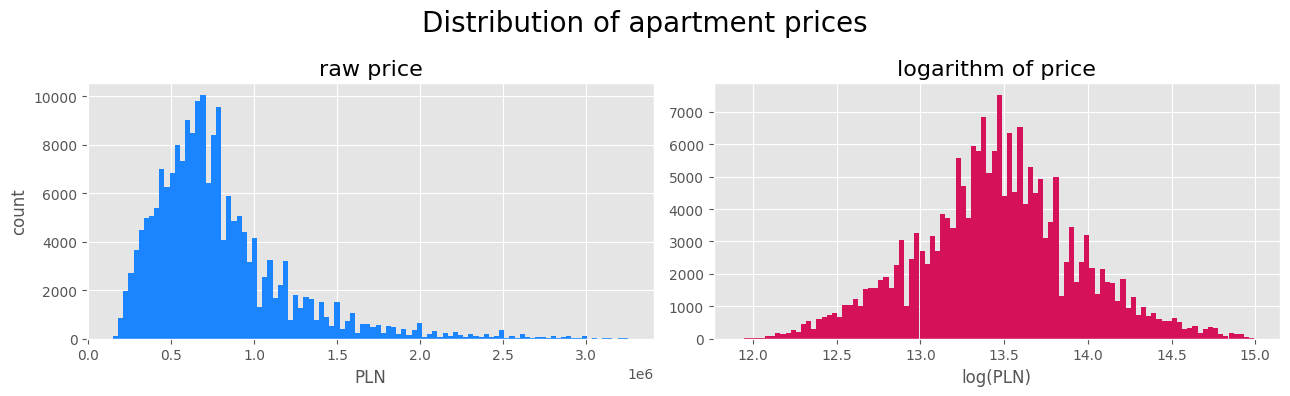

In [8]:
fig, axes = plt.subplots(
    1, 2,
    figsize = (13, 4)
)

axes[0].hist(
    df["price"].dropna(),
    bins = 100,
    color = "#1A85FF",
    edgecolor = "none"
)
axes[0].set_title(
    "raw price",
    fontsize = 16
)
axes[0].set_xlabel(
    "PLN",
    fontsize = 12
)
axes[0].set_ylabel(
    "count",
    fontsize = 12
)

axes[1].hist(
    np.log(df['price'].dropna()),
    bins = 100,
    color = "#D41159",
    edgecolor = "none"
)
axes[1].set_title(
    "logarithm of price",
    fontsize = 16
)
axes[1].set_xlabel(
    "log(PLN)",
    fontsize = 12
)
axes[1].set_ylabel(
    ""
)

fig.suptitle(
    "Distribution of apartment prices",
    fontsize = 20
)
plt.tight_layout()
plt.show()
plt.close()

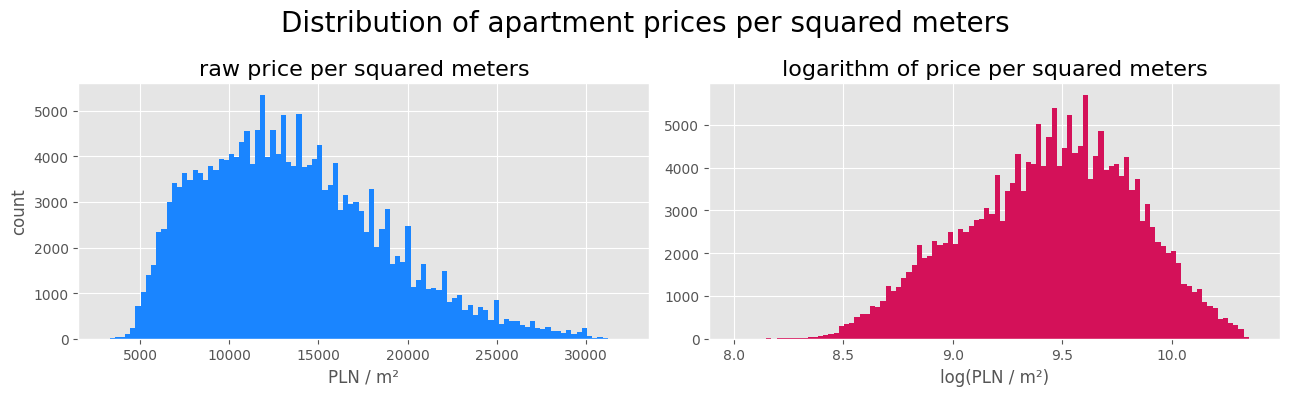

In [9]:
fig, axes = plt.subplots(
    1, 2,
    figsize = (13, 4)
)

axes[0].hist(
    df["price"] / df["squareMeters"].dropna(),
    bins = 100,
    color = "#1A85FF",
    edgecolor = "none"
)
axes[0].set_title(
    "raw price per squared meters",
    fontsize = 16
)
axes[0].set_xlabel(
    "PLN / m²",
    fontsize = 12
)
axes[0].set_ylabel(
    "count",
    fontsize = 12
)

axes[1].hist(
    np.log(df["price"] / df["squareMeters"].dropna()),
    bins = 100,
    color = "#D41159",
    edgecolor = "none"
)
axes[1].set_title(
    "logarithm of price per squared meters",
    fontsize = 16
)
axes[1].set_xlabel(
    "log(PLN / m²)",
    fontsize = 12
)
axes[1].set_ylabel(
    ""
)

fig.suptitle(
    "Distribution of apartment prices per squared meters",
    fontsize = 20
)
plt.tight_layout()
plt.show()
plt.close()

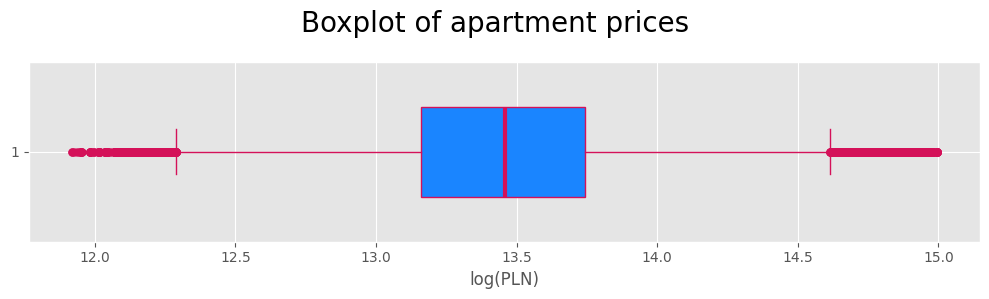

In [10]:
fig, ax = plt.subplots(
    figsize = (10, 3)
)

bp = ax.boxplot(
    x = np.log(df['price'].dropna()),
    vert = False,
    patch_artist = True,
    widths = 0.5
)

bp["boxes"][0].set_facecolor("#1A85FF")
bp["boxes"][0].set_edgecolor("#D41159")
bp["boxes"][0].set_linewidth(1)

bp["whiskers"][0].set_color("#D41159")
bp["whiskers"][1].set_color("#D41159")

bp["caps"][0].set_color("#D41159")
bp["caps"][1].set_color("#D41159")

bp["medians"][0].set_color("#D41159")
bp["medians"][0].set_linewidth(3)

bp["fliers"][0].set_marker("o")
bp["fliers"][0].set_markerfacecolor("#D41159")
bp["fliers"][0].set_markeredgecolor("#D41159")
bp["fliers"][0].set_markersize(5)

fig.suptitle(
    "Boxplot of apartment prices",
    fontsize = 20
)
ax.set_xlabel(
    "log(PLN)",
    fontsize = 12
)
ax.set_ylabel(
    ""
)

plt.tight_layout()
plt.show()
plt.close()

Cities

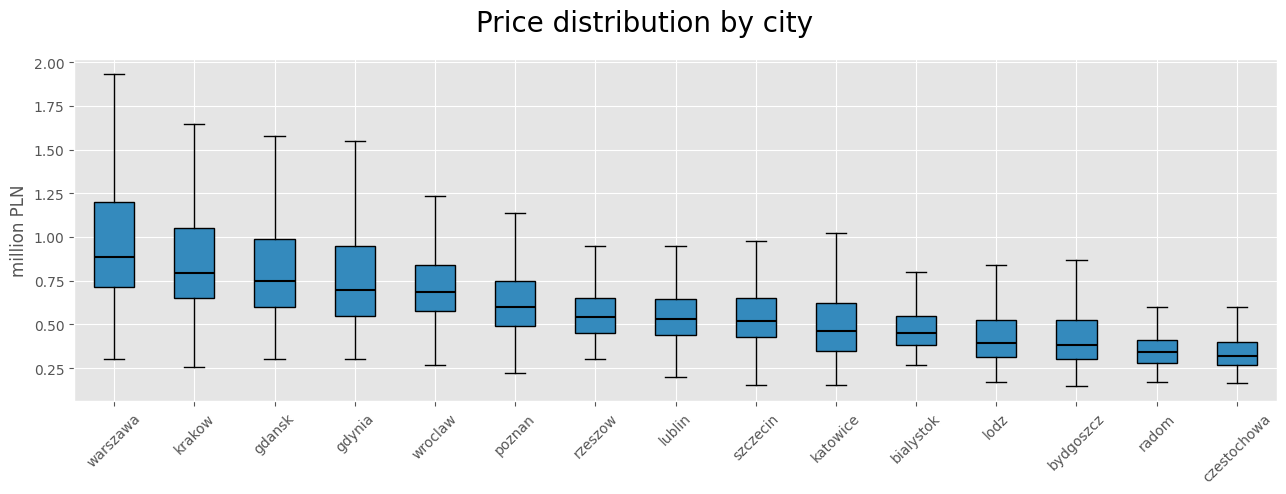

In [11]:
fig, ax = plt.subplots(
    figsize=(13, 5)
)

bp = ax.boxplot(
    [
        df.loc[df["city"] == city, "price"].dropna().values / 10**6 for city in (
            df.groupby("city")["price"].median().sort_values(
                ascending = False
            ).index.tolist()
        )
    ],
    patch_artist = True,
    showfliers = False,
    medianprops = dict(
        color = "black",
        linewidth = 1.5
    )
)
ax.set_xticklabels(
    df.groupby("city")["price"].median().sort_values(
        ascending = False
    ).index.tolist(),
    rotation = 45
)

fig.suptitle(
    "Price distribution by city",
    fontsize = 20
)
ax.set_xlabel(
    ""
)
ax.set_ylabel(
    "million PLN",
    fontsize = 12
)

plt.tight_layout()
plt.show()
plt.close()

Time trend

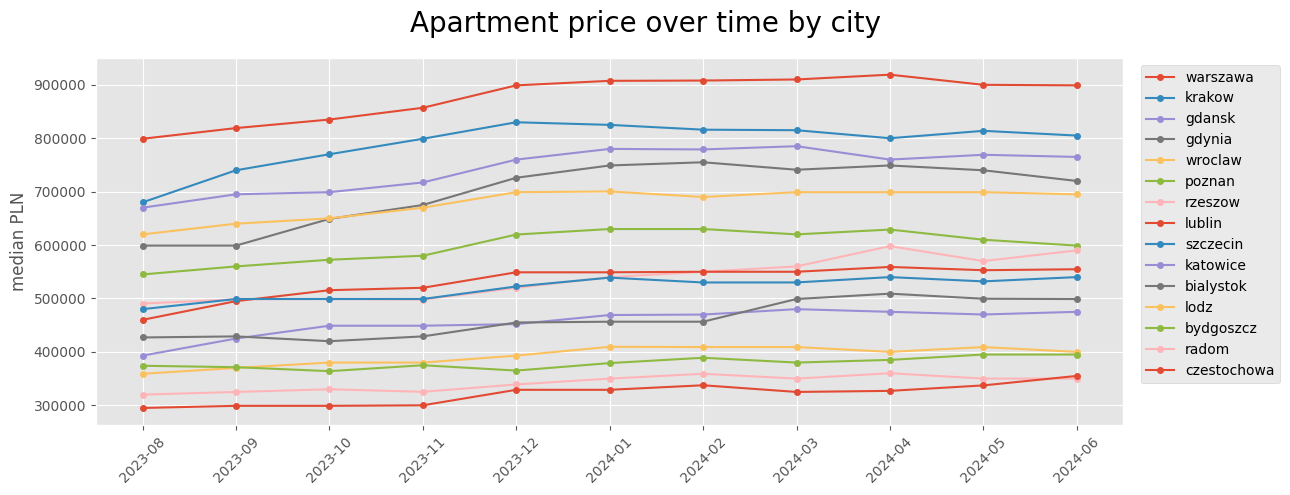

In [12]:
city_monthly = (
    df.groupby(['city', 'snapshot_month'], observed=True)['price']
      .median()
      .reset_index()
)

fig, ax = plt.subplots(
    figsize=(13, 5)
)

for city in (
    df.groupby("city")["price"].median().sort_values(
        ascending = False
    ).index.tolist()
):
    sub = city_monthly[city_monthly["city"] == city]
    ax.plot(
        sub["snapshot_month"].astype(str),
        sub["price"],
        marker = "o",
        linewidth = 1.5,
        label = city,
        markersize = 4
    )
plt.xticks(
    rotation = 45
)

fig.suptitle(
    "Apartment price over time by city",
    fontsize = 20
)
ax.set_xlabel(
    ""
)
ax.set_ylabel(
    "median PLN",
    fontsize = 12
)

ax.legend(
    bbox_to_anchor = (1.01, 1),
    loc = "upper left",
    fontsize = 10
)

plt.tight_layout()
plt.show()
plt.close()

Summary

* `condition` and `buildingMaterial` have high (over 30%) missing rate
* `squareMeters` has the strongest positive correlation and `centreDistance` shows a negative correlation with `price`
* `price` is right-skewed and `log(price)` is approximately follows normal distribution
* strong city-level heterogeneity in median price
* clearly visible time trends differ across cities